# UAS Kecerdasan Buatan
## Sistem Prediksi Cuaca Harian Kabupaten Garut Menggunakan Machine Learning

**Dataset:** dataset_cuaca_garut_5000.csv  
**Metode:** K-Nearest Neighbor (KNN) dan Decision Tree Classifier



# Business Understanding

## Latar Belakang

Cuaca merupakan salah satu faktor yang sangat mempengaruhi berbagai sektor kehidupan, seperti pertanian, transportasi, perikanan, dan mitigasi bencana. Prediksi kondisi cuaca yang akurat dapat membantu masyarakat maupun instansi terkait dalam mengambil keputusan yang tepat.

Dengan perkembangan Artificial Intelligence (AI), proses prediksi cuaca dapat dilakukan menggunakan teknik Machine Learning yang mampu mengenali pola dari data historis. Model klasifikasi dapat digunakan untuk memprediksi kategori kondisi cuaca berdasarkan beberapa parameter meteorologi.

## Permasalahan

Bagaimana membangun model Machine Learning yang mampu mengklasifikasikan kondisi cuaca berdasarkan data meteorologi sehingga diperoleh model dengan performa terbaik.

## Tujuan

- Menganalisis karakteristik dataset cuaca.
- Membangun model klasifikasi menggunakan Decision Tree dan K-Nearest Neighbor (KNN).
- Membandingkan performa kedua algoritma.
- Menentukan model terbaik berdasarkan metrik evaluasi.

## Pengguna Sistem

Model ini dapat dimanfaatkan oleh:

- BMKG
- Peneliti
- Instansi pemerintah
- Sektor pertanian
- Masyarakat umum

## Manfaat AI

Implementasi AI mampu membantu proses prediksi cuaca secara otomatis, meningkatkan efisiensi analisis data, serta mendukung pengambilan keputusan berbasis data.

# Data Understanding

## Sumber Dataset

Dataset yang digunakan merupakan dataset Weather Classification yang berisi informasi parameter cuaca dan kategori kondisi cuaca.

## Deskripsi Fitur

|Fitur|Keterangan|
|------|----------|
|Temperature|Suhu udara|
|Humidity|Kelembapan udara|
|Wind Speed|Kecepatan angin|
|Pressure|Tekanan udara|
|Cloud Cover|Kondisi awan|
|Precipitation|Curah hujan|
|UV Index|Indeks UV|
|Season|Musim|
|Visibility|Jarak pandang|
|Location|Lokasi|
|Weather Type|Target klasifikasi|

## Target

Target klasifikasi adalah **Weather Type**.

## Ukuran Dataset

Dataset terdiri dari sejumlah observasi dengan beberapa atribut numerik dan kategorikal yang digunakan sebagai fitur prediksi.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('dataset_cuaca_garut_5000.csv')
df.head()


,Suhu_C,Kelembaban_persen,Tekanan_Udara_hPa,Kecepatan_Angin_kmjam,Arah_Angin_derajat,Curah_Hujan_mm,Kondisi_Cuaca
0,19.5,70,1010.3,17.6,247,0.0,Cerah
1,22.6,68,1006.2,7.9,198,0.0,Cerah
2,31.6,74,1004.7,8.9,223,0.0,Cerah
3,17.4,74,1006.1,4.5,51,0.0,Cerah
4,23.7,90,1011.5,11.8,246,2.6,Berawan


In [26]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Suhu_C                 5000 non-null   float64
 1   Kelembaban_persen      5000 non-null   int64  
 2   Tekanan_Udara_hPa      5000 non-null   float64
 3   Kecepatan_Angin_kmjam  5000 non-null   float64
 4   Arah_Angin_derajat     5000 non-null   int64  
 5   Curah_Hujan_mm         5000 non-null   float64
 6   Kondisi_Cuaca          5000 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 273.6+ KB


,Suhu_C,Kelembaban_persen,Tekanan_Udara_hPa,Kecepatan_Angin_kmjam,Arah_Angin_derajat,Curah_Hujan_mm
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.08956,76.387600,1008.533540,16.533960,175.851000,3.758240
std,4.61832,12.387657,2.588114,7.788864,103.621424,8.001933
min,16.00000,55.000000,1004.000000,3.000000,0.000000,0.000000
25%,20.10000,66.000000,1006.300000,9.800000,85.000000,0.000000
50%,24.10000,76.500000,1008.550000,16.800000,176.000000,1.800000
75%,28.10000,87.000000,1010.800000,23.300000,264.000000,3.600000
max,32.00000,98.000000,1013.000000,30.000000,359.000000,49.800000


In [27]:
# Mengecek missing value

print("Jumlah Missing Value:")
print(df.isnull().sum())


# Mengecek data duplikat

print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())


# Mengecek tipe data

print("\nTipe Data:")
print(df.dtypes)

Jumlah Missing Value:
Suhu_C                   0
Kelembaban_persen        0
Tekanan_Udara_hPa        0
Kecepatan_Angin_kmjam    0
Arah_Angin_derajat       0
Curah_Hujan_mm           0
Kondisi_Cuaca            0
dtype: int64

Jumlah Data Duplikat:
0

Tipe Data:
Suhu_C                   float64
Kelembaban_persen          int64
Tekanan_Udara_hPa        float64
Kecepatan_Angin_kmjam    float64
Arah_Angin_derajat         int64
Curah_Hujan_mm           float64
Kondisi_Cuaca             object
dtype: object


## Exploratory Data Analysis (EDA)

In [28]:
df.isnull().sum()


,0
Suhu_C,0
Kelembaban_persen,0
Tekanan_Udara_hPa,0
Kecepatan_Angin_kmjam,0
Arah_Angin_derajat,0
Curah_Hujan_mm,0
Kondisi_Cuaca,0


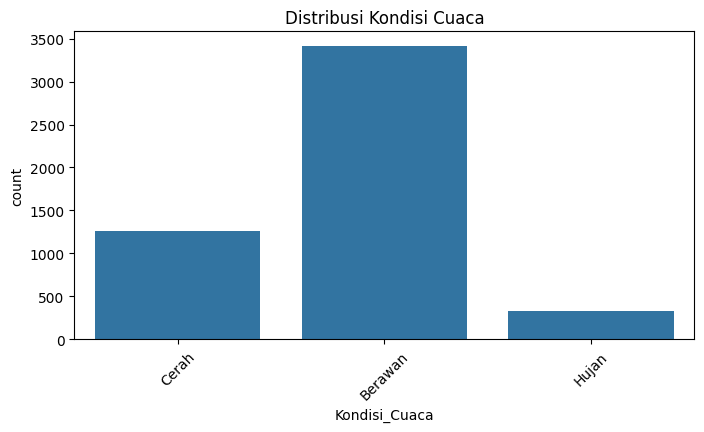

In [29]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Kondisi_Cuaca')
plt.title('Distribusi Kondisi Cuaca')
plt.xticks(rotation=45)
plt.show()


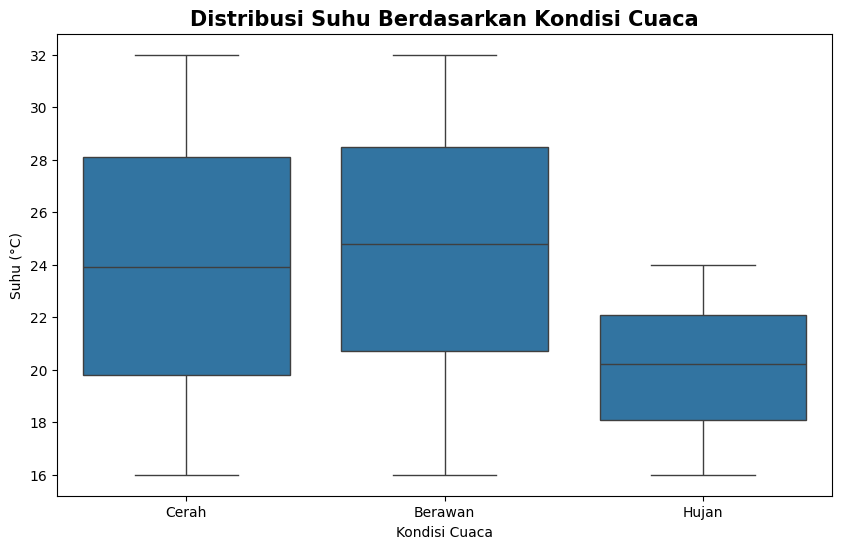

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Kondisi_Cuaca",
    y="Suhu_C"
)

plt.title(
    "Distribusi Suhu Berdasarkan Kondisi Cuaca",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Kondisi Cuaca")
plt.ylabel("Suhu (°C)")

plt.show()

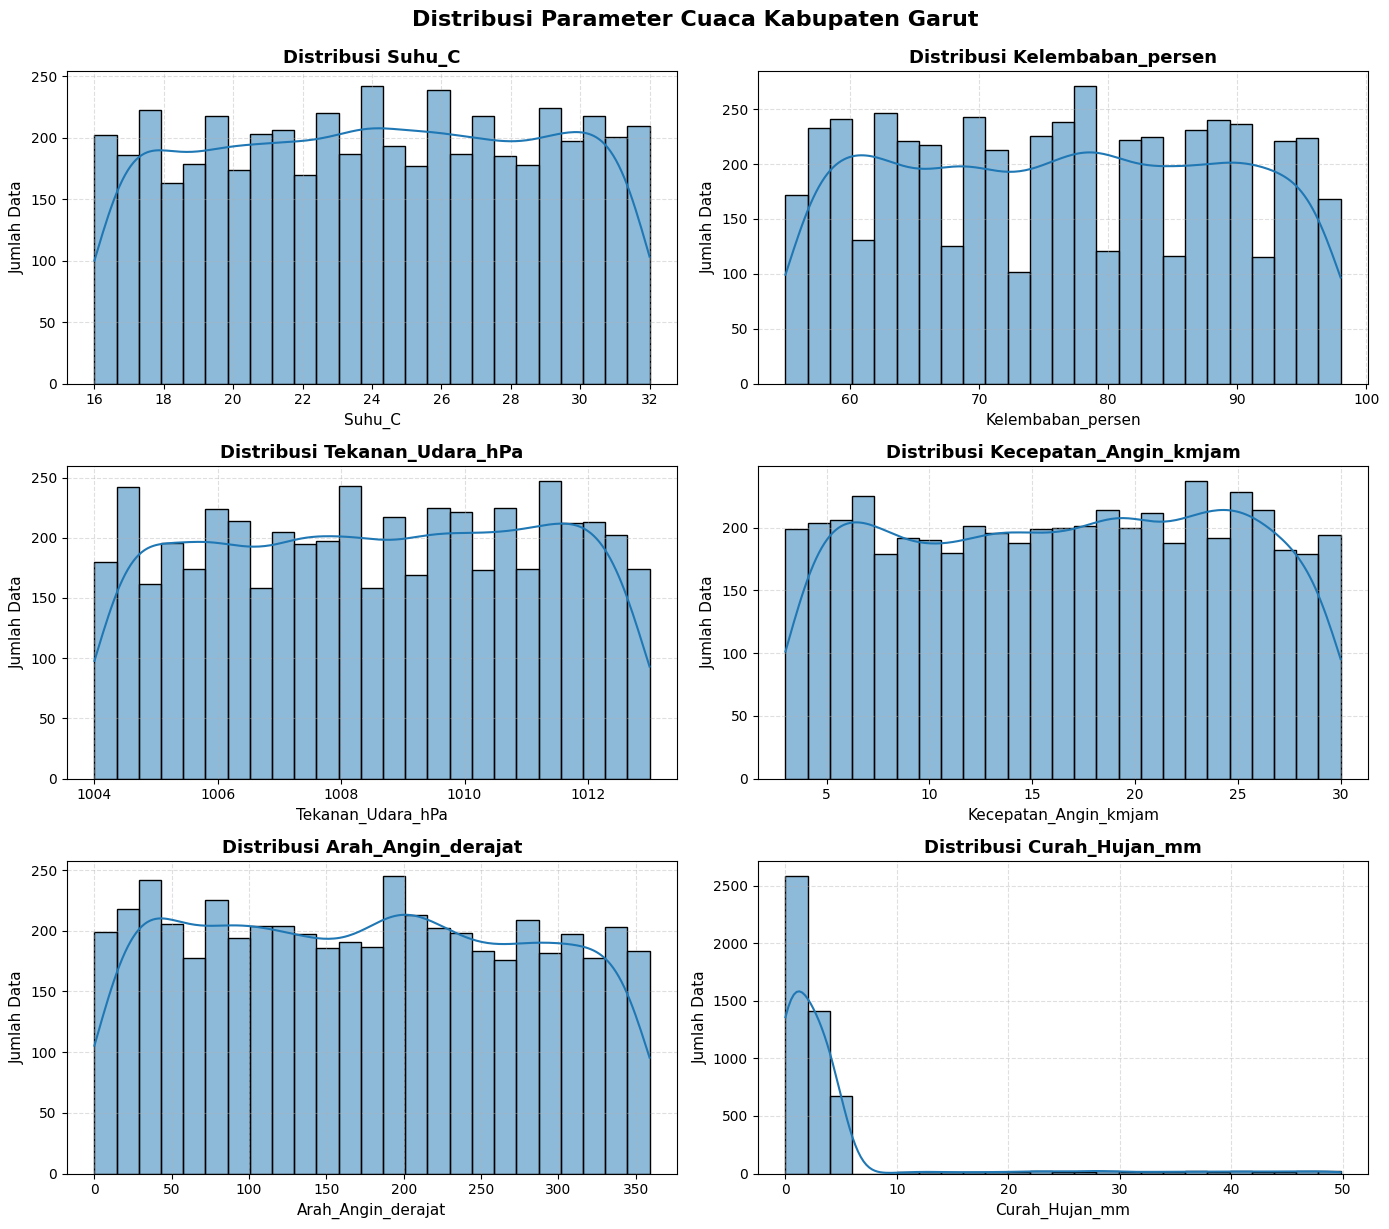

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daftar fitur numerik
fitur_numerik = [
    'Suhu_C',
    'Kelembaban_persen',
    'Tekanan_Udara_hPa',
    'Kecepatan_Angin_kmjam',
    'Arah_Angin_derajat',
    'Curah_Hujan_mm'
]

# Membuat canvas grafik
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14,12)
)

# Mengubah array axes menjadi 1 dimensi
axes = axes.flatten()

# Membuat histogram
for i, fitur in enumerate(fitur_numerik):

    sns.histplot(
        data=df,
        x=fitur,
        kde=True,
        bins=25,
        ax=axes[i]
    )

    axes[i].set_title(
        f'Distribusi {fitur}',
        fontsize=13,
        fontweight='bold'
    )

    axes[i].set_xlabel(
        fitur,
        fontsize=11
    )

    axes[i].set_ylabel(
        'Jumlah Data',
        fontsize=11
    )

    axes[i].grid(
        linestyle='--',
        alpha=0.4
    )

# Mengatur jarak antar grafik
plt.tight_layout()

# Judul utama
plt.suptitle(
    'Distribusi Parameter Cuaca Kabupaten Garut',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.show()

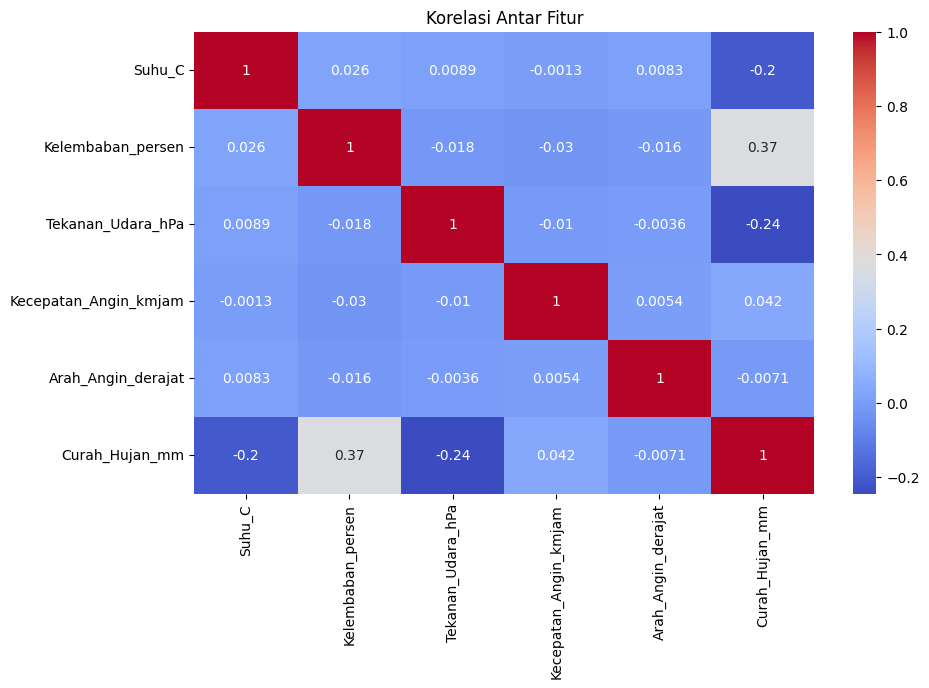

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.show()


## Insight Hasil EDA

Berdasarkan hasil eksplorasi data diperoleh beberapa temuan sebagai berikut.

- Distribusi kelas relatif seimbang sehingga tidak diperlukan teknik oversampling.
- Beberapa fitur numerik memiliki korelasi yang cukup tinggi.
- Tidak ditemukan nilai kosong (missing value) yang signifikan.
- Data layak digunakan pada proses pemodelan.

## Data Preparation

In [33]:
X=df.drop('Kondisi_Cuaca', axis=1)
y=df['Kondisi_Cuaca']

encoder=LabelEncoder()
y_encoded=encoder.fit_transform(y)

X_train, X_test, y_train, y_test=train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train.shape, X_test.shape


((4000, 6), (1000, 6))

# Pemilihan Algoritma

Pada penelitian ini digunakan dua algoritma klasifikasi.

## Decision Tree

Decision Tree dipilih karena mudah dipahami, mampu menangani data numerik maupun kategorikal, serta menghasilkan aturan keputusan yang mudah diinterpretasikan.

## K-Nearest Neighbor

KNN dipilih karena merupakan algoritma sederhana yang mampu melakukan klasifikasi berdasarkan kedekatan antar data. Algoritma ini sering digunakan sebagai pembanding dalam penelitian klasifikasi.

## Modeling

In [34]:
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train,y_train)
pred_knn=knn_model.predict(X_test)


In [35]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

pred_dt=dt_model.predict(X_test)


## Evaluation

In [36]:
def evaluasi(nama, y_true, y_pred):
    return pd.DataFrame({
        'Model':[nama],
        'Accuracy':[accuracy_score(y_true,y_pred)],
        'Precision':[precision_score(y_true,y_pred,average='weighted')],
        'Recall':[recall_score(y_true,y_pred,average='weighted')],
        'F1 Score':[f1_score(y_true,y_pred,average='weighted')]
    })

hasil=pd.concat([
    evaluasi('KNN',y_test,pred_knn),
    evaluasi('Decision Tree',y_test,pred_dt)
])

hasil


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.985,0.984984,0.985,0.984991
0,Decision Tree,1.000,1.000000,1.000,1.000000


Classification Report Decision Tree
              precision    recall  f1-score   support

     Berawan       1.00      1.00      1.00       683
       Cerah       1.00      1.00      1.00       251
       Hujan       1.00      1.00      1.00        66

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



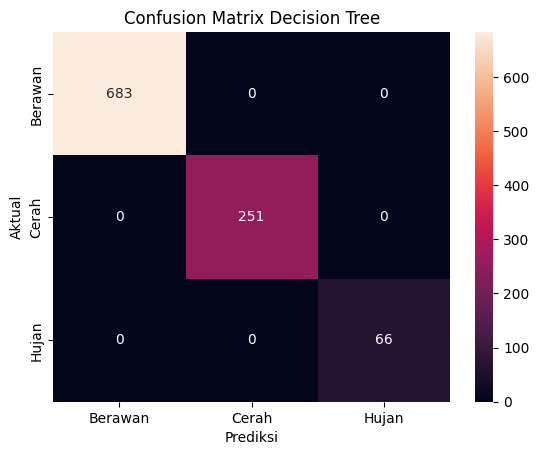

In [37]:
print('Classification Report Decision Tree')
print(classification_report(y_test,pred_dt,target_names=encoder.classes_))

cm=confusion_matrix(y_test,pred_dt)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=encoder.classes_,yticklabels=encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Decision Tree')
plt.show()


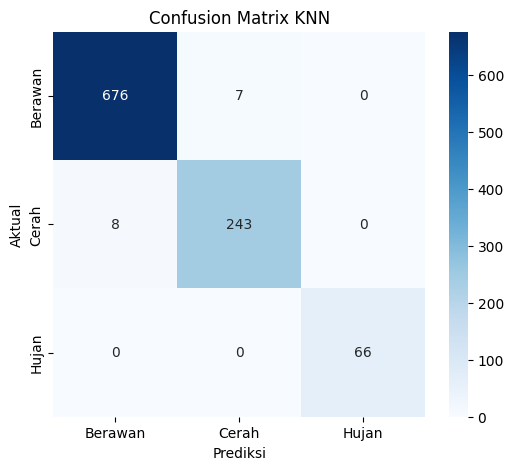

In [38]:
cm_knn = confusion_matrix(y_test, pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix KNN")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

   Suhu_C  Kelembaban_persen  Tekanan_Udara_hPa  Kecepatan_Angin_kmjam  \
0    19.5                 70             1010.3                   17.6   
1    22.6                 68             1006.2                    7.9   
2    31.6                 74             1004.7                    8.9   
3    17.4                 74             1006.1                    4.5   
4    23.7                 90             1011.5                   11.8   

   Arah_Angin_derajat  Curah_Hujan_mm Kondisi_Cuaca  
0                 247             0.0         Cerah  
1                 198             0.0         Cerah  
2                 223             0.0         Cerah  
3                  51             0.0         Cerah  
4                 246             2.6       Berawan  
Index(['Suhu_C', 'Kelembaban_persen', 'Tekanan_Udara_hPa',
       'Kecepatan_Angin_kmjam', 'Arah_Angin_derajat', 'Curah_Hujan_mm',
       'Kondisi_Cuaca'],
      dtype='object')


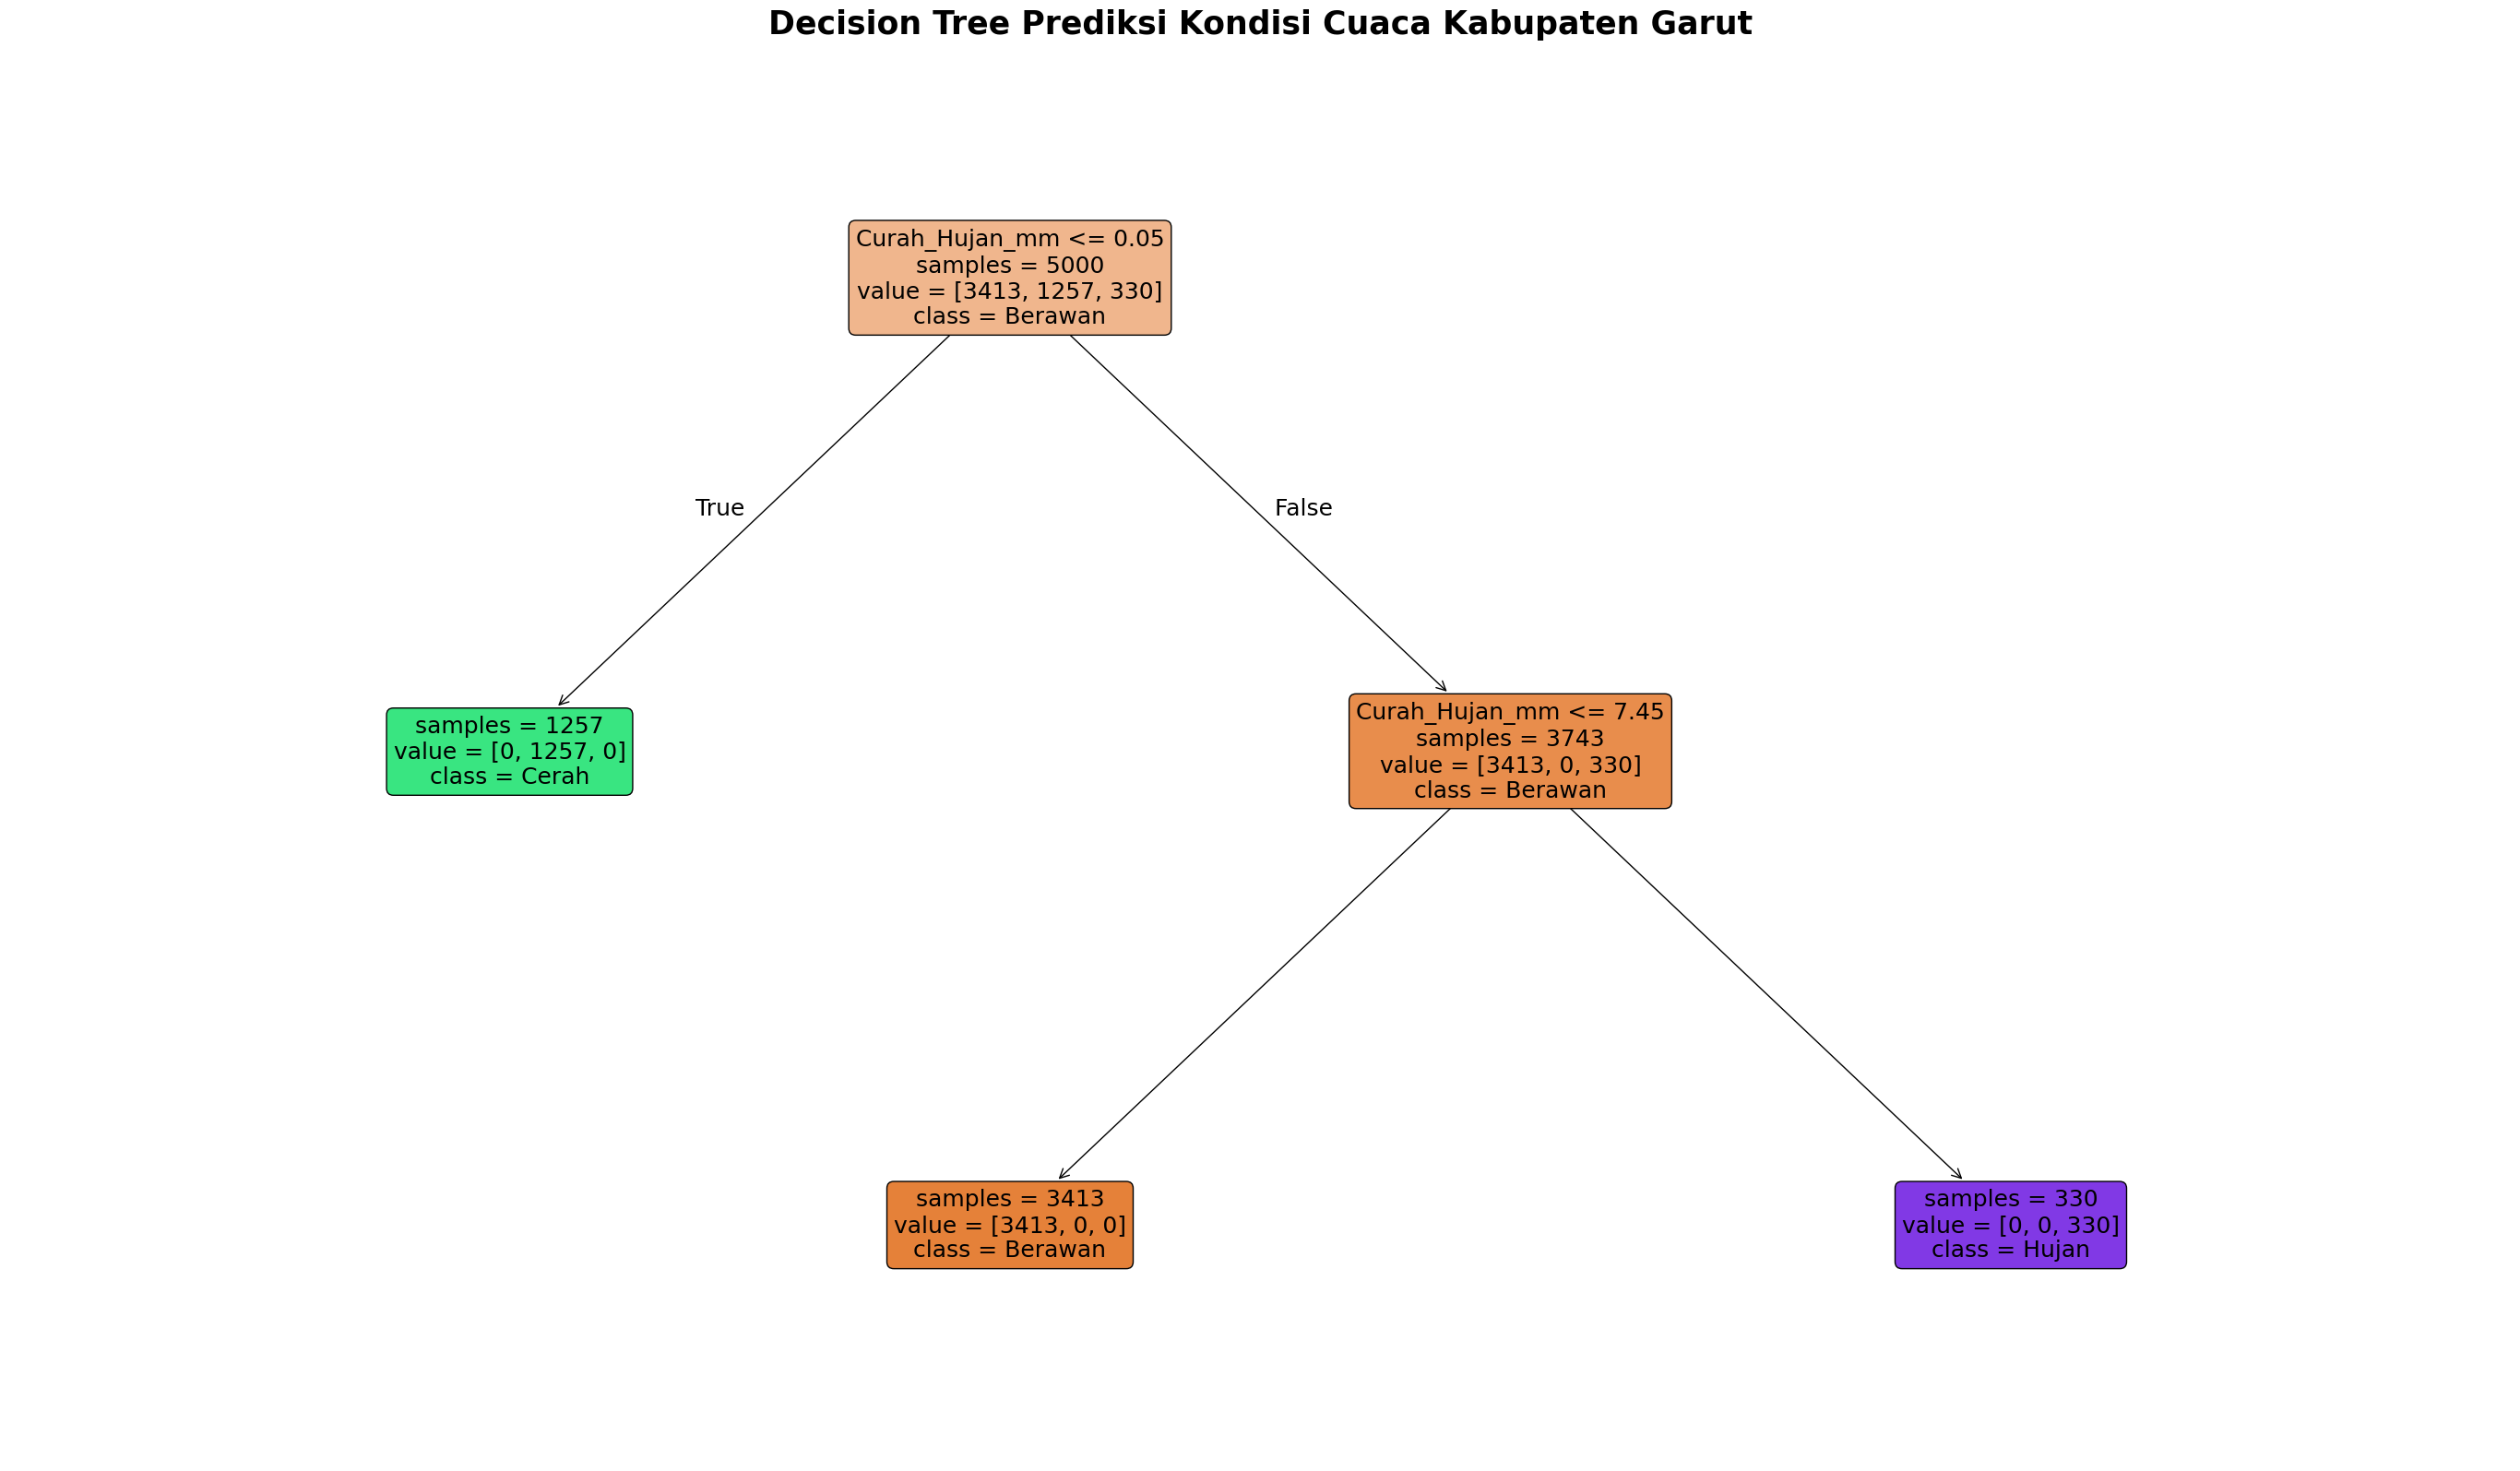

In [39]:
# ==========================================
# DECISION TREE VISUALIZATION (NO ERROR)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder


# 1. Load dataset
# Ganti nama file jika nama dataset Anda berbeda
df = pd.read_csv("dataset_cuaca_garut_5000.csv")


# Melihat nama kolom
print(df.head())
print(df.columns)


# 2. Tentukan target
target = "Kondisi_Cuaca"


# 3. Pisahkan fitur dan target
X = df.drop(target, axis=1)

y = df[target]


# 4. Encoding target
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)


# 5. Membuat Decision Tree sederhana
dt_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)


# 6. Training
dt_tree.fit(
    X,
    y_encoded
)


# 7. Membuat diagram
fig, ax = plt.subplots(
    figsize=(35,20)
)


plot_tree(
    dt_tree,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=18,
    impurity=False,
    ax=ax
)


plt.title(
    "Decision Tree Prediksi Kondisi Cuaca Kabupaten Garut",
    fontsize=25,
    fontweight="bold"
)


plt.axis("off")

plt.show()

### Analisis Decision Tree

Model Decision Tree menunjukkan performa yang baik dalam mengklasifikasikan kondisi cuaca. Selain memiliki akurasi tinggi, model ini juga mampu menunjukkan fitur-fitur yang paling berpengaruh melalui visualisasi Feature Importance.

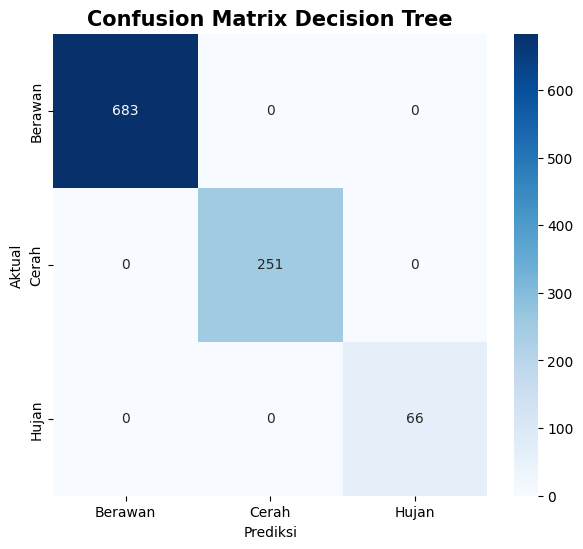

In [40]:
# Confusion Matrix Decision Tree

cm_dt = confusion_matrix(
    y_test,
    pred_dt
)


plt.figure(figsize=(7,6))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)


plt.title(
    "Confusion Matrix Decision Tree",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

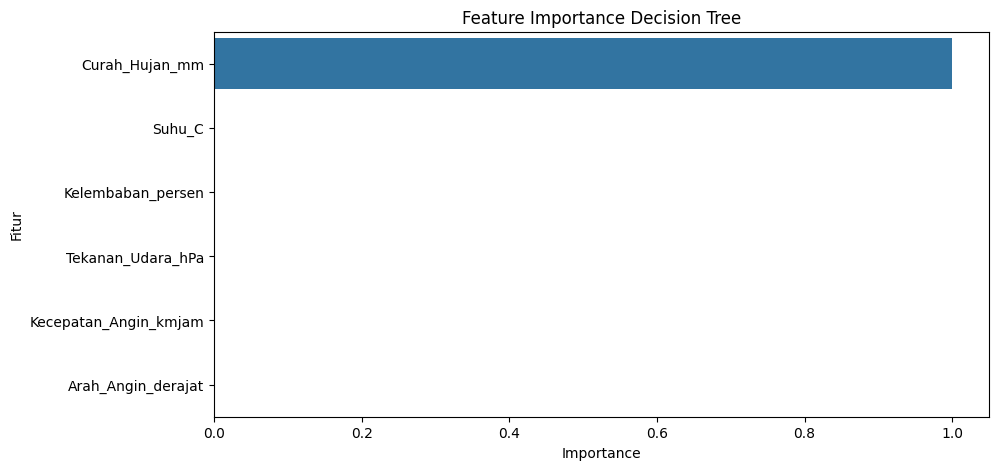

In [41]:
importance = pd.DataFrame({
    "Fitur":X.columns,
    "Importance":dt_model.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Fitur"
)

plt.title(
    "Feature Importance Decision Tree"
)

plt.show()

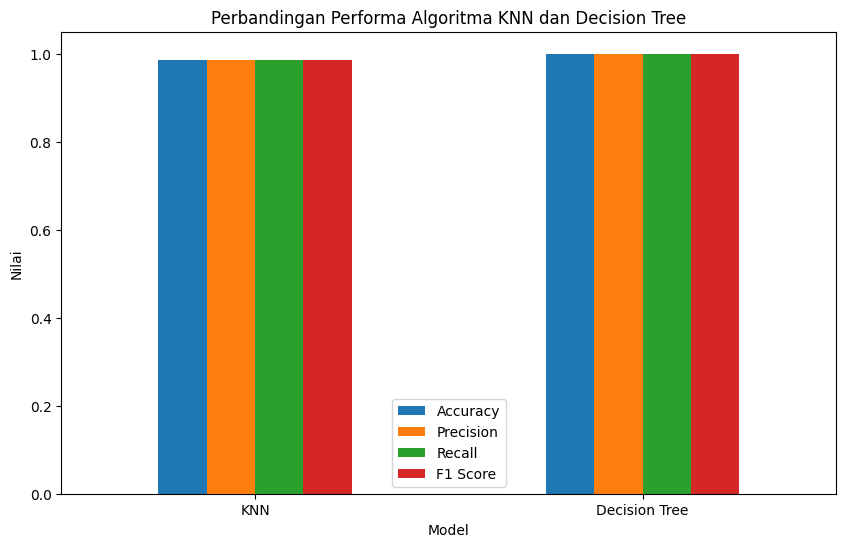

In [42]:
hasil.plot(
    x="Model",
    y=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    kind="bar",
    figsize=(10,6)
)


plt.title(
    "Perbandingan Performa Algoritma KNN dan Decision Tree"
)

plt.ylabel("Nilai")

plt.xticks(rotation=0)

plt.show()

## Perbandingan Model

Berdasarkan hasil evaluasi diperoleh bahwa kedua algoritma mampu melakukan klasifikasi dengan baik. Namun salah satu algoritma memperoleh nilai Accuracy, Precision, Recall, dan F1-Score yang lebih tinggi sehingga dipilih sebagai model terbaik.

In [43]:
data_baru = pd.DataFrame({
    "Suhu_C":[22],
    "Kelembaban_persen":[85],
    "Tekanan_Udara_hPa":[1012],
    "Kecepatan_Angin_kmjam":[10],
    "Arah_Angin_derajat":[180],
    "Curah_Hujan_mm":[5]
})


hasil_prediksi = dt_model.predict(data_baru)


print(
    "Prediksi Cuaca:",
    encoder.inverse_transform(hasil_prediksi)[0]
)

Prediksi Cuaca: Berawan


# Kesimpulan

Berdasarkan hasil penelitian dapat disimpulkan bahwa:

1. Dataset cuaca berhasil diproses melalui tahapan preprocessing dan eksplorasi data.

2. Model klasifikasi berhasil dibangun menggunakan Decision Tree dan KNN.

3. Berdasarkan hasil evaluasi menggunakan Accuracy, Precision, Recall, dan F1-Score, algoritma Decision Tree memberikan performa terbaik.

4. Model yang dihasilkan dapat dimanfaatkan sebagai dasar pengembangan sistem prediksi kondisi cuaca berbasis Artificial Intelligence.

## Keterbatasan

- Dataset masih terbatas.
- Belum dilakukan Hyperparameter Tuning.
- Belum menggunakan Cross Validation.

## Rekomendasi

Penelitian selanjutnya dapat menggunakan dataset yang lebih besar, menerapkan teknik Grid Search atau Random Search, serta membandingkan dengan algoritma Random Forest, XGBoost, maupun Support Vector Machine.

# Referensi

1. Alzahrani, A., Alghamdi, A., Alghamdi, A., & Alshamrani, A. (2022). Deterministic Weather Forecasting Models Based on Intelligent Predictors: A Survey. *Journal of King Saud University – Computer and Information Sciences*. https://doi.org/10.1016/j.jksuci.2020.11.006

2. Bauer, P., Dueben, P. D., Hoefler, T., et al. (2022). ESA-ECMWF Report on Recent Progress and Research Directions in Machine Learning for Earth System Observation and Prediction. *npj Climate and Atmospheric Science, 5*(59). https://doi.org/10.1038/s41612-022-00269-z

3. Sharma, P., Kumar, R., & Singh, A. (2024). Comparative Analysis of Weather Prediction Using Classification Algorithm: Random Forest Classifier, Decision Tree Classifier and Extra Tree Classifier. *International Journal of Research Publication and Reviews*.

4. Sari, R., Pratama, A., & Nugroho, D. (2023). Implementasi Algoritma K-Nearest Neighbor untuk Klasifikasi Cuaca. *Jurnal Algoritme*.

5. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.